# Plots for `data/alpha_sweep_extended.csv` (v2 — inline backend)

Same figures as `alpha_sweep_extended_plots.ipynb`, but with `%matplotlib inline` so it renders in the
IDE instead of blocking on a GUI window. MWPM vs correlated matching (Pearl $\alpha$), d=5 and d=7,
rotated surface code, circuit-level depolarizing noise.

1. **LER vs $p$** — MWPM and CM at every $\alpha$, per distance.
2. **LER relative to hard CM ($\alpha=1$) vs $\alpha$** — the U-shape and how the optimum shifts with $p$.
3. **Optimal $\alpha^\star$ vs $p$** — the headline trend.
4. **Gain ratios vs $p$** — CM/MWPM, best-$\alpha$/MWPM, best-$\alpha$/CM.

In [1]:
%matplotlib inline
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = os.path.abspath(os.path.join(os.getcwd(), "..")) if os.path.basename(os.getcwd()) == "notebooks" else os.getcwd()
os.makedirs(os.path.join(ROOT, "plots"), exist_ok=True)
plt.rcParams.update({"figure.dpi": 100, "font.size": 10, "axes.grid": True, "grid.alpha": 0.3})

df = pd.read_csv(os.path.join(ROOT, "data", "alpha_sweep_extended.csv"))
df["alpha"] = pd.to_numeric(df["alpha"], errors="coerce")
DISTS = sorted(df.distance.unique())
ALPHAS = sorted(df[df.decoder == "cm"].alpha.unique())
print(f"distances={DISTS}  alphas={ALPHAS}")

def sub(d):
    return df[df.distance == d]

def get(d, p, alpha=None):
    """(ler, std) for MWPM (alpha=None) or CM at a given alpha."""
    s = sub(d)
    r = s[(s.decoder == "mwpm") & (s.p == p)] if alpha is None else \
        s[(s.decoder == "cm") & (s.p == p) & (np.isclose(s.alpha, alpha))]
    return (float(r.ler.iloc[0]), float(r.ler_std.iloc[0])) if len(r) else (np.nan, np.nan)

def ps_of(d):
    return sorted(sub(d).p.unique())

distances=[np.int64(5), np.int64(7)]  alphas=[np.float64(0.1), np.float64(0.2), np.float64(0.3), np.float64(0.4), np.float64(0.5), np.float64(0.9), np.float64(1.0)]


## 1. LER vs $p$

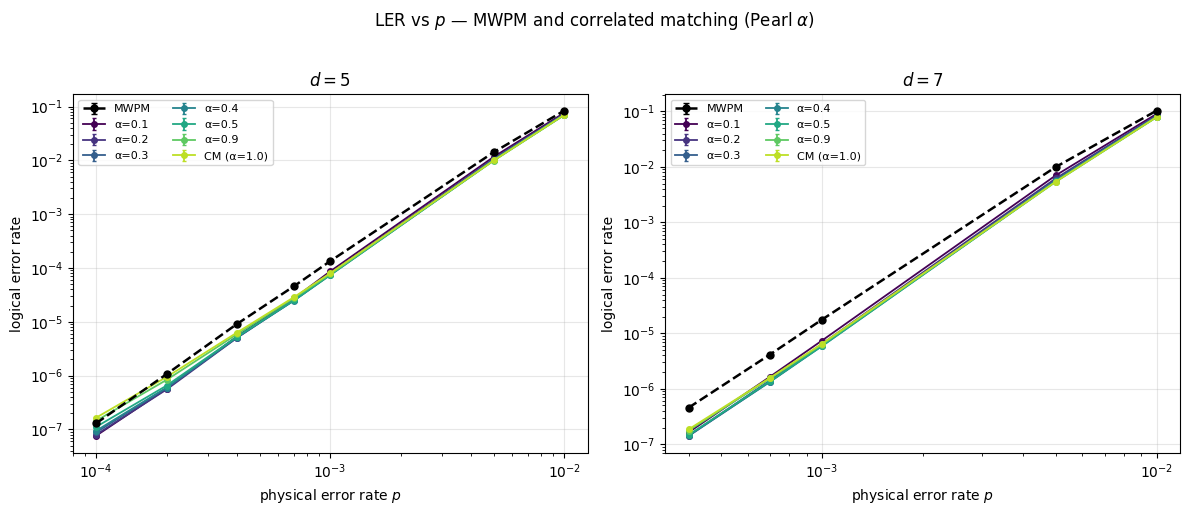

In [2]:
fig, axes = plt.subplots(1, len(DISTS), figsize=(6 * len(DISTS), 5), squeeze=False)
acolors = plt.cm.viridis(np.linspace(0, 0.9, len(ALPHAS)))
for ax, d in zip(axes[0], DISTS):
    ps = np.array(ps_of(d))
    mw = np.array([get(d, p) for p in ps])
    ax.errorbar(ps, mw[:, 0], yerr=mw[:, 1], fmt="k--o", lw=1.8, ms=5, capsize=2, label="MWPM", zorder=5)
    for a, c in zip(ALPHAS, acolors):
        v = np.array([get(d, p, a) for p in ps])
        lbl = "CM (α=1.0)" if a == 1.0 else f"α={a:g}"
        ax.errorbar(ps, v[:, 0], yerr=v[:, 1], fmt="o-", color=c, ms=4, lw=1.3, capsize=1.5, label=lbl)
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_xlabel("physical error rate $p$"); ax.set_ylabel("logical error rate")
    ax.set_title(f"$d={d}$"); ax.legend(fontsize=8, ncol=2)
fig.suptitle("LER vs $p$ — MWPM and correlated matching (Pearl $\\alpha$)", y=1.02)
fig.tight_layout()
fig.savefig(os.path.join(ROOT, "plots", "ext_ler_vs_p.png"), dpi=200, bbox_inches="tight")
plt.show()

## 2. LER relative to hard CM ($\alpha=1$) vs $\alpha$

Below 1.0 beats hard CM; the minimum marks the best $\alpha$. Dashed grey = CM ($\alpha=1$); $\times$ =
MWPM/CM. The minimum marches right as $p$ grows.

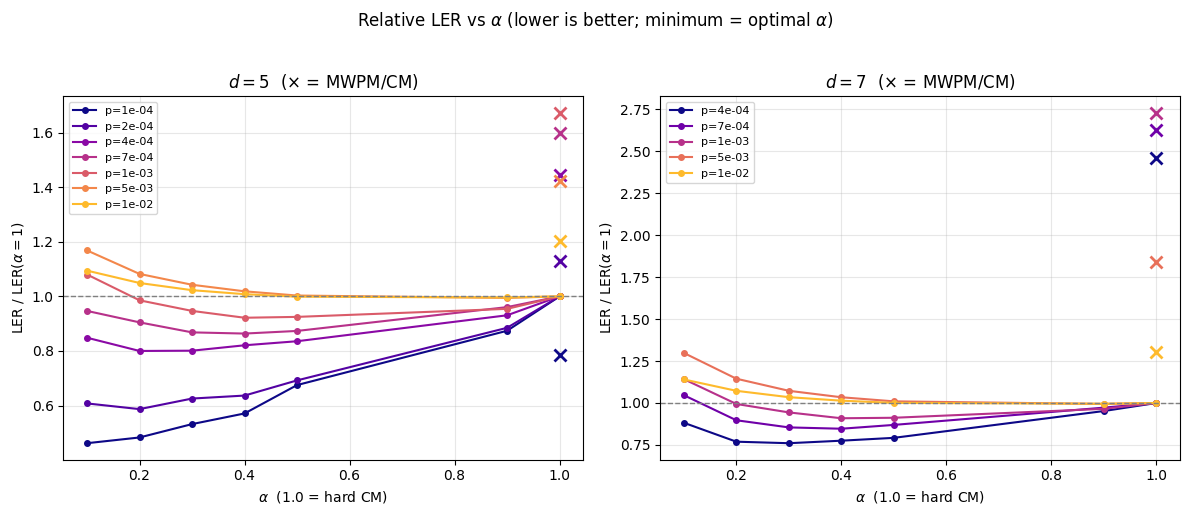

In [3]:
fig, axes = plt.subplots(1, len(DISTS), figsize=(6 * len(DISTS), 5), squeeze=False)
for ax, d in zip(axes[0], DISTS):
    ps = ps_of(d)
    pcolors = plt.cm.plasma(np.linspace(0, 0.85, len(ps)))
    for p, c in zip(ps, pcolors):
        cm1 = get(d, p, 1.0)[0]
        ax.plot(ALPHAS, [get(d, p, a)[0] / cm1 for a in ALPHAS], "o-", color=c, ms=4, label=f"p={p:.0e}")
        ax.plot([1.0], [get(d, p)[0] / cm1], "x", color=c, ms=9, mew=2)
    ax.axhline(1.0, color="gray", ls="--", lw=1)
    ax.set_xlabel("$\\alpha$  (1.0 = hard CM)"); ax.set_ylabel("LER / LER($\\alpha=1$)")
    ax.set_title(f"$d={d}$  ($\\times$ = MWPM/CM)"); ax.legend(fontsize=8)
fig.suptitle("Relative LER vs $\\alpha$ (lower is better; minimum = optimal $\\alpha$)", y=1.02)
fig.tight_layout()
fig.savefig(os.path.join(ROOT, "plots", "ext_relative_ler_vs_alpha.png"), dpi=200, bbox_inches="tight")
plt.show()

## 3. Optimal $\alpha^\star$ vs $p$

$\alpha^\star(p)=\arg\min_\alpha \mathrm{LER}$. The grid is coarse (gap 0.5–0.9), so read the trend, not a
precise optimum.

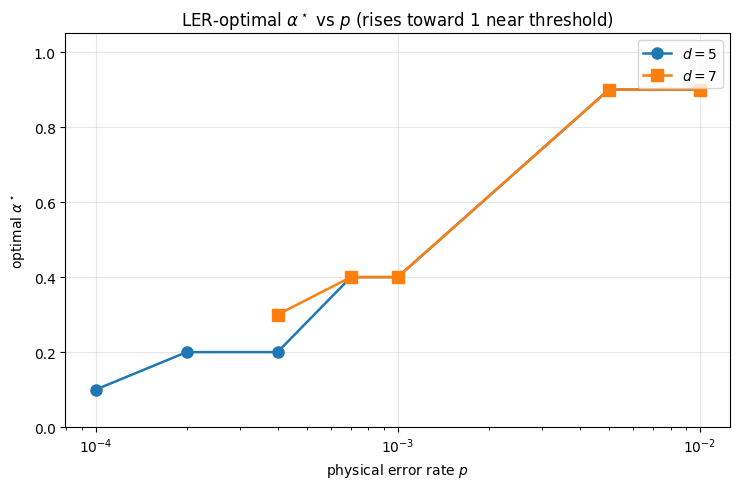

In [4]:
fig, ax = plt.subplots(figsize=(7.5, 5))
for d, mk in zip(DISTS, ["o-", "s-"]):
    ps = ps_of(d)
    astar = [ALPHAS[int(np.argmin([get(d, p, a)[0] for a in ALPHAS]))] for p in ps]
    ax.plot(ps, astar, mk, ms=8, lw=1.8, label=f"$d={d}$")
ax.set_xscale("log")
ax.set_xlabel("physical error rate $p$"); ax.set_ylabel("optimal $\\alpha^\\star$")
ax.set_ylim(0, 1.05); ax.set_title("LER-optimal $\\alpha^\\star$ vs $p$ (rises toward 1 near threshold)")
ax.legend()
fig.tight_layout()
fig.savefig(os.path.join(ROOT, "plots", "ext_optimal_alpha_vs_p.png"), dpi=200, bbox_inches="tight")
plt.show()

## 4. Gain ratios vs $p$

Hard CM vs MWPM (do correlations help?), best-$\alpha$ vs MWPM (total gain), best-$\alpha$ vs hard CM
(Pearl-damping gain). **Above 1 = worse than baseline** — note hard CM crossing above MWPM at the lowest $p$.

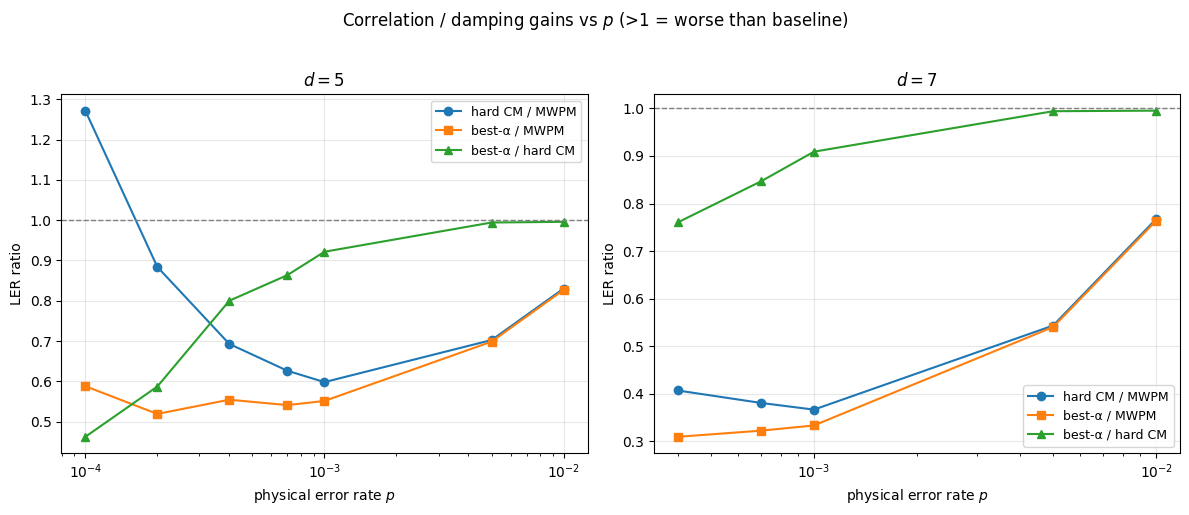

In [5]:
fig, axes = plt.subplots(1, len(DISTS), figsize=(6 * len(DISTS), 5), squeeze=False)
for ax, d in zip(axes[0], DISTS):
    ps = np.array(ps_of(d))
    mw = np.array([get(d, p)[0] for p in ps])
    cm1 = np.array([get(d, p, 1.0)[0] for p in ps])
    best = np.array([min(get(d, p, a)[0] for a in ALPHAS) for p in ps])
    ax.plot(ps, cm1 / mw, "o-", label="hard CM / MWPM")
    ax.plot(ps, best / mw, "s-", label="best-α / MWPM")
    ax.plot(ps, best / cm1, "^-", label="best-α / hard CM")
    ax.axhline(1.0, color="gray", ls="--", lw=1)
    ax.set_xscale("log")
    ax.set_xlabel("physical error rate $p$"); ax.set_ylabel("LER ratio")
    ax.set_title(f"$d={d}$"); ax.legend(fontsize=9)
fig.suptitle("Correlation / damping gains vs $p$ (>1 = worse than baseline)", y=1.02)
fig.tight_layout()
fig.savefig(os.path.join(ROOT, "plots", "ext_gain_ratios_vs_p.png"), dpi=200, bbox_inches="tight")
plt.show()

## Notes

- **Fig 1:** at the lowest $p$, CM($\alpha=1$) sits *above* MWPM (hard CM hurts); small-$\alpha$ curves
  sit well below.
- **Fig 2:** U-shape; the best-$\alpha$ minimum moves rightward as $p$ rises.
- **Fig 3:** $\alpha^\star$ rises from ~0.1 deep sub-threshold toward ~0.9 near threshold.
- **Fig 4:** the `hard CM / MWPM` curve exceeding 1 at $p=10^{-4}$ is the 'hard CM worse than MWPM deep
  sub-threshold' effect.